# Métricas para Clasificación Binaria

### El dataset pathmnist

In [139]:
import numpy as np

data = np.load("pathmnist.npz")
print(data.files)

['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']


In [140]:
X = np.concatenate([data["train_images"], data["val_images"], data["test_images"]], axis=0)
y = np.concatenate([data["train_labels"], data["val_labels"], data["test_labels"]], axis=0)

X = X.reshape(len(X), -1)
print(X.shape, y.shape)

(107180, 2352) (107180, 1)


Como puedes ver, cada imágen está formada por $2342$ $28x28x3$ características (los pixeles). Podemos visualizar unas cuantas imágenes junto a sus etiquetas de la siguiente manera para hacernos una idea del tipo de datos al que nos enfrentamos.

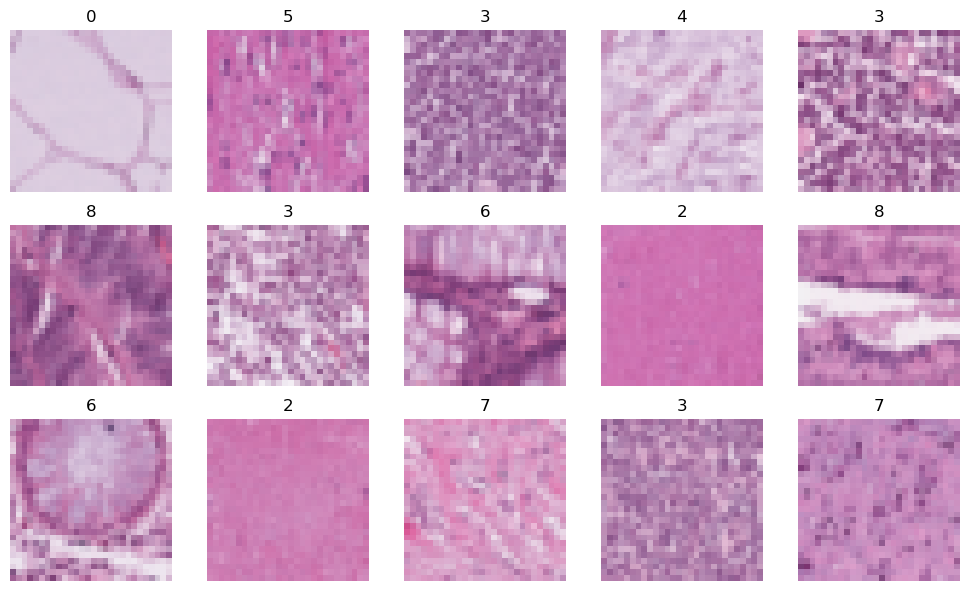

In [141]:
%matplotlib inline

import matplotlib.pyplot as plt
import random
import numpy as np

r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(X)-1)
        img = X[ix].reshape(28, 28, 3)   
        
        plt.imshow(img.astype(np.uint8))  
        plt.axis("off")
        plt.title(y[ix].item()) 

plt.tight_layout()
plt.show()


Por último, vamos a extraer $89996$ imágenes para entrenar nuestro modelo y $10,004$ para evaluarlo y calcular las diferentes métricas que veremos.

In [142]:
data = np.load("pathmnist.npz")

X_train, y_train = data["train_images"] / 255.0, data["train_labels"].flatten()
X_val,   y_val   = data["val_images"]   / 255.0, data["val_labels"].flatten()
X_test,  y_test  = data["test_images"]  / 255.0, data["test_labels"].flatten()

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(89996, 28, 28, 3) (89996,)
(10004, 28, 28, 3) (10004,)
(7180, 28, 28, 3) (7180,)


## Entrenando un clasificador binario

Para llevar a cabo una tarea de clasificación binaria necesitamos que nuestro dataset esté dividido en dos clases, sin embargo el dataset, cómo ya hemos visto, tiene $9$ clases (todos las patologías de colon $1$ y $9$). En este caso, vamos a entrenar un modelo para clasificar imágenes de la patología 5 frente al resto, es decir, consideraremos la clase 5 como positiva y todas las demás como negativas

In [143]:
y_train_5 = (y_train == 5).astype(int)
y_test_5  = (y_test == 5).astype(int)


In [ ]:
import numpy as np

def bce(y, y_hat):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return - np.mean(y*np.log(y_hat) + (1 - y)*np.log(1 - y_hat))

def sigmoid(x):
    x = np.clip(x, -500, 500)  
    return 1 / (1 + np.exp(-x))

class Perceptron:
    def __init__(self, size):
        self.w = np.random.normal(
            loc=0.0,
            scale=np.sqrt(2/(size+1)),
            size=(size,)
        )
        self.ws = []
        self.activation = sigmoid
        self.loss = bce

    def __call__(self, w, x):
        return self.activation(np.dot(x, w))

    def fit(self, x, y, epochs, lr, verbose=True):
        x = np.c_[np.ones(len(x)), x]  # bias
        for epoch in range(1, epochs+1):
            # forward
            y_hat = self(self.w, x)
            # loss
            l = self.loss(y, y_hat)
            # gradiente
            dldh = (y_hat - y)
            dhdw = x
            dldw = np.dot(dldh, dhdw)
            # actualizar pesos
            self.w = self.w - lr * dldw
            # guardar
            self.ws.append(self.w.copy())
            # log
            if verbose:
                print(f"Epoch {epoch}/{epochs} Loss {l}")


In [145]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

perceptron = Perceptron(X_train_flat.shape[1] + 1)
epochs, lr = 10, 1e-7   
perceptron.fit(X_train_flat, y_train_5, epochs, lr)



Epoch 1/10 Loss 0.4317943715585522
Epoch 2/10 Loss 0.4111736149086041
Epoch 3/10 Loss 0.40879081938751083
Epoch 4/10 Loss 0.40874031217190937
Epoch 5/10 Loss 0.40869091478263725
Epoch 6/10 Loss 0.40864170092571866
Epoch 7/10 Loss 0.40859266009595907
Epoch 8/10 Loss 0.4085437911347551
Epoch 9/10 Loss 0.40849509298188014
Epoch 10/10 Loss 0.4084465645862881


## Métricas

Vamos a ver las métricas más utilizadas en la evaluación de modelos de clasificación binaria. Para calcular cualquier métrica vamos a necesitar ser capaces de generar predicciones con nuestro modelo. En posts anterior ya hemos visto cómo podemos hacerlo.

In [146]:
def evaluate(perceptron, x, t=0.5):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    y = perceptron(w, x)
    return (y > t).astype(int)  


### *Accuracy*

La *accuracy* mide el porcentaje de ejemplos correctamente clasificados por el modelo. Su valor va de $0$ (ningún acierto) a $1$ (todos correctos) y suele expresarse como porcentaje.

In [147]:
def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

In [148]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

y_pred = evaluate(perceptron, X_train_flat)
accuracy(y_pred, y_train_5)


np.float64(0.8646384283745945)

In [149]:
X_test_flat = X_test.reshape(len(X_test), -1)

y_pred = evaluate(perceptron, X_test_flat)
accuracy(y_pred, y_test_5)


np.float64(0.9175487465181058)

Cómo podemos ver nuestro modelo tiene una precisión cercana al $92 \%$ tanto para el conjunto de entrenamiento como para el de evaluación. ¿Es este un buen modelo? A priori podríamos pensar que si, ya que nuestro modelo acierta $9$ de cada $10$ imágenes

In [150]:
1 - y_train_5.mean(), 1 - y_test_5.mean()

(np.float64(0.8646384283745945), np.float64(0.9175487465181058))

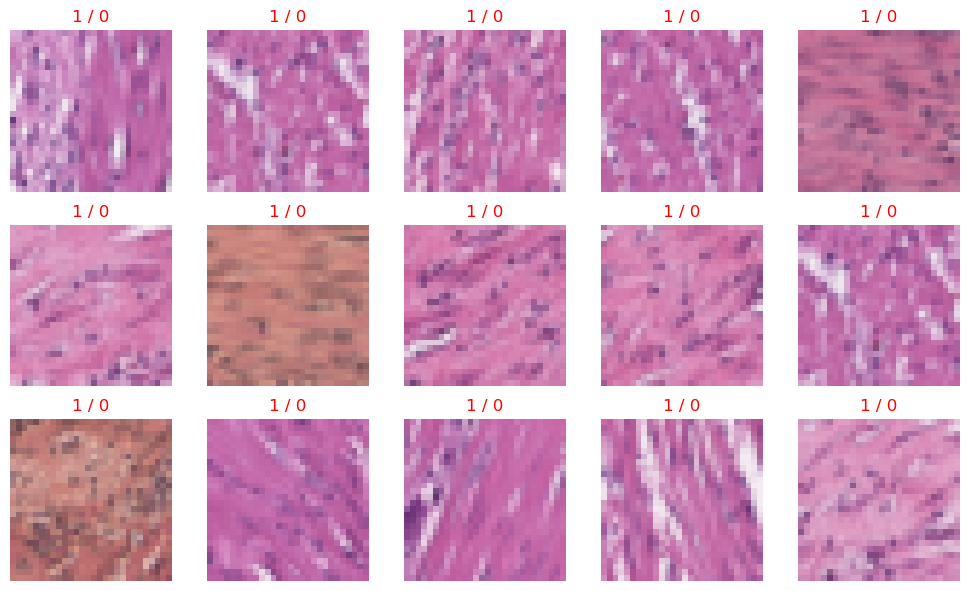

In [151]:
import matplotlib.pyplot as plt
import random

r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))
fives = (y_test_5 == 1)
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)        
        ix = random.randint(0, len(X_test[fives]) - 1)
        img = X_test[fives][ix]
        plt.imshow(img)  
        plt.axis("off")
        y_pred = evaluate(perceptron, img.reshape(1, -1))
        color = "green" if y_test_5[fives][ix] == y_pred[0] else "red"
        plt.title(f"{y_test_5[fives][ix]} / {y_pred[0]}", color=color)

plt.tight_layout()
plt.show()


En este caso en particular podemos obtener un mejor modelo simplemente entrenando durante más epochs

In [174]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)
    
perceptron = Perceptron(X_train_flat.shape[1] + 1)
epochs, lr =190, 1e-6

perceptron.fit(X_train_flat, y_train_5, epochs, lr, verbose=False)
y_pred = evaluate(perceptron, X_test_flat)
accuracy(y_pred, y_test_5)


np.float64(0.8612813370473538)

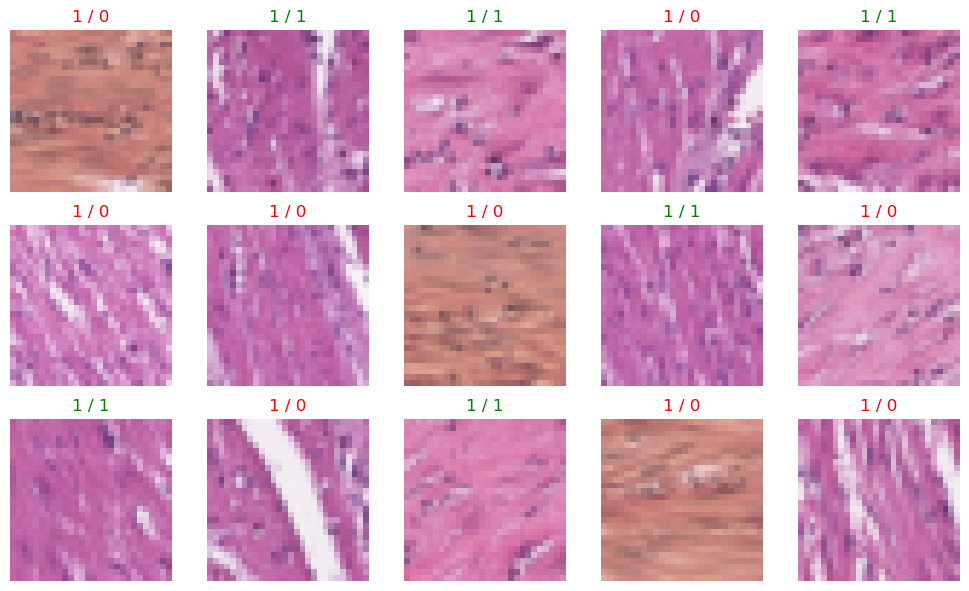

In [175]:
import matplotlib.pyplot as plt
import random

r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))
fives = (y_test_5 == 1)
for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)        
        ix = random.randint(0, len(X_test[fives]) - 1)
        img = X_test[fives][ix]
        plt.imshow(img)  
        plt.axis("off")
        y_pred = evaluate(perceptron, img.reshape(1, -1))
        color = "green" if y_test_5[fives][ix] == y_pred[0] else "red"
        plt.title(f"{y_test_5[fives][ix]} / {y_pred[0]}", color=color)

plt.tight_layout()
plt.show()


In [176]:
from sklearn.metrics import accuracy_score

y_pred = evaluate(perceptron, X_test_flat)
accuracy_score(y_test_5, y_pred)

0.8612813370473538

### La Matriz de Confusión

Una matriz de confusión nos va a indicar exactamente cuales son los puntos fuertes y débiles de nuestro clasificador. Para cada clase, vamos a calcular cuantos elementos han sido bien clasificados por nuestro modelo y cuántos han sido confundidos con otras clases (esta matriz nos será muy útil en clasificación en varias clases también).

In [177]:
TP = np.sum((y_pred == 1) & (y_test_5 == 1))
TN = np.sum((y_pred == 0) & (y_test_5 == 0))
FP = np.sum((y_pred == 1) & (y_test_5 == 0))
FN = np.sum((y_pred == 0) & (y_test_5 == 1))

CM = [[TN, FP],
      [FN, TP]]
CM

[[np.int64(5837), np.int64(751)], [np.int64(245), np.int64(347)]]

En esta matriz podemos observar:
    
- Verdaderos Positivos (TP, *True Positives*): elementos que nuestro modelo clasifica correctamente como la clase que nos interesa, la clase positiva (fila 1, columna 1).
- Verdaderos Negativos (TN, *True Negatives*): elementos que nuestro modelo clasifica correctamente como la clase negativa (fila 0, columna 0).
- Falsos Positivos (FP, *False Positives*): elementos que nuestro modelo clasifica erróneamente como la clase positiva (fila 0, columna 1).
- Falsos Negativos (FN, *False Negatives*): elementos que nuestro modelo clasifica erróneamente como la clase negativa (fila 1, columna 0).

In [178]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_5, y_pred)

array([[5837,  751],
       [ 245,  347]])

### *Precision* y *Recall*

La *accuracy* puede ser engañosa, por eso usamos métricas más informativas como *precision* y *recall*. 

- **Precision** mide qué proporción de las predicciones positivas son realmente correctas:
    $$
    precision = \frac{TP}{TP+FP}
    $$
    Un valor alto indica pocos falsos positivos.

- **Recall** mide qué proporción de los positivos reales son detectados por el modelo:
    $$
    recall = \frac{TP}{TP+FN}
    $$
    Un valor alto indica pocos falsos negativos.

En resumen, *precision* nos dice cuántos de los positivos predichos lo son de verdad, y *recall* cuántos de los positivos reales detectamos.

In [179]:
def precision(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1))
    FP = np.sum((y_pred == 1) & (y == 0))
    return TP / (TP + FP)

def recall(y_pred, y):
    TP = np.sum((y_pred == 1) & (y == 1))
    FN = np.sum((y_pred == 0) & (y == 1))
    return TP / (TP + FN)

In [180]:
X_test_flat = X_test.reshape(len(X_test), -1)


y_pred = evaluate(perceptron, X_test_flat)
precision(y_pred, y_test_5), recall(y_pred, y_test_5)


(np.float64(0.31602914389799636), np.float64(0.5861486486486487))

In [181]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_test_5, y_pred), recall_score(y_test_5, y_pred)

(0.31602914389799636, 0.5861486486486487)

En función de la aplicación en la que estemos trabajando vamos a querer optimizar una métrica u otra. En aplicaciones en las que tener falsos positivos sea perjudicial (por ejemplo, aplicaciones de seguridad) querremos modelos con un buena *precision*, mientras que en aplicaciones en las que tener falsos negativos sea perjudicial (por ejemplo, sistemas de diagnóstico médico) querremos modelos con buen *recall*. Una vez nuestro modelo ha sido entrenado, podemos ajustar estas métricas variando el valor del *threshold* utilizado en la evaluación. A esto se le conoce como el *precision-recall trade off*.

In [182]:
X_test_flat = X_test.reshape(len(X_test), -1)

for t in np.linspace(0.1,0.9,20):
    y_pred = evaluate(perceptron, X_test_flat, t)
    print(f"Threshold: {t:.3f} Precision {precision(y_pred, y_test_5):.4f} Recall {recall(y_pred, y_test_5):.4f}")

Threshold: 0.100 Precision 0.1673 Recall 0.9679
Threshold: 0.142 Precision 0.1852 Recall 0.9443
Threshold: 0.184 Precision 0.1958 Recall 0.9172
Threshold: 0.226 Precision 0.2033 Recall 0.8851
Threshold: 0.268 Precision 0.2103 Recall 0.8429
Threshold: 0.311 Precision 0.2276 Recall 0.8041
Threshold: 0.353 Precision 0.2521 Recall 0.7652
Threshold: 0.395 Precision 0.2679 Recall 0.7061
Threshold: 0.437 Precision 0.2869 Recall 0.6571
Threshold: 0.479 Precision 0.3101 Recall 0.6166
Threshold: 0.521 Precision 0.3163 Recall 0.5439
Threshold: 0.563 Precision 0.3418 Recall 0.4983
Threshold: 0.605 Precision 0.3645 Recall 0.4409
Threshold: 0.647 Precision 0.3832 Recall 0.3767
Threshold: 0.689 Precision 0.3810 Recall 0.2973
Threshold: 0.732 Precision 0.3543 Recall 0.2280
Threshold: 0.774 Precision 0.3246 Recall 0.1470
Threshold: 0.816 Precision 0.2292 Recall 0.0743
Threshold: 0.858 Precision 0.1085 Recall 0.0236
Threshold: 0.900 Precision 0.0123 Recall 0.0017


Cómo se puede observar, incrementar el valor de una de las métricas implica que la otra va a disminuir (es por esto que se le llama *trade-off* ya que tenemos que llegar a un compromiso). Así pues, escogeremos un valor del *threshold* que se ajusto a los criterios de diseño de nuestra aplicación en particular (en función de la cantidad de falsos positivos y falsos negativos que estemos dispuestos a asumir).

### F1-Score

Una métrica rápida que nos va a decir si nuestro modelo tiene buena *precision* y *recall* es el *F1-score*.

$$  F_1 = 2 \times \frac{precision \times recall}{precision + recall} $$

Es una métrica muy usada ya que aglutina la información de ambas métricas, sin embargo va a favorecer mucho aquellos modelos con un valor similar de *precision* y *recall*, lo cual ya hemos comentado que no es siempre lo que vamos a querer.

In [183]:
X_test_flat = X_test.reshape(len(X_test), -1)
y_pred = evaluate(perceptron, X_test_flat)

p = precision_score(y_test_5, y_pred)
r = recall_score(y_test_5, y_pred)

f1 = 2*(p*r)/(p+r)
f1

0.41065088757396456

In [184]:
from sklearn.metrics import f1_score

f1_score(y_test_5, y_pred)

0.4106508875739645

### La curva ROC

Podemos visualizar rápidamente el comportamiento de un modelo para varios *thresholds* con la llamada curva ROC (*Receiver Operating Characteristic*). En ella representamos el ratio de verdaderos positivos (TPR) contra el ratio de falsos positivos (FPR), definidos de la siguiente manera:

$$ TPR = \frac{TP}{TP+FN} $$

$$ FPR = \frac{FP}{FP+TN} $$

In [185]:
def evaluate2(perceptron, x):
    w = perceptron.ws[-1]
    x = np.c_[np.ones(len(x)), x]
    y = perceptron(w, x)
    return y

In [186]:
from sklearn.metrics import roc_curve

X_test_flat = X_test.reshape(len(X_test), -1)

y_pred2 = evaluate2(perceptron, X_test_flat)
fpr, tpr, thresholds = roc_curve(y_test_5, y_pred2)

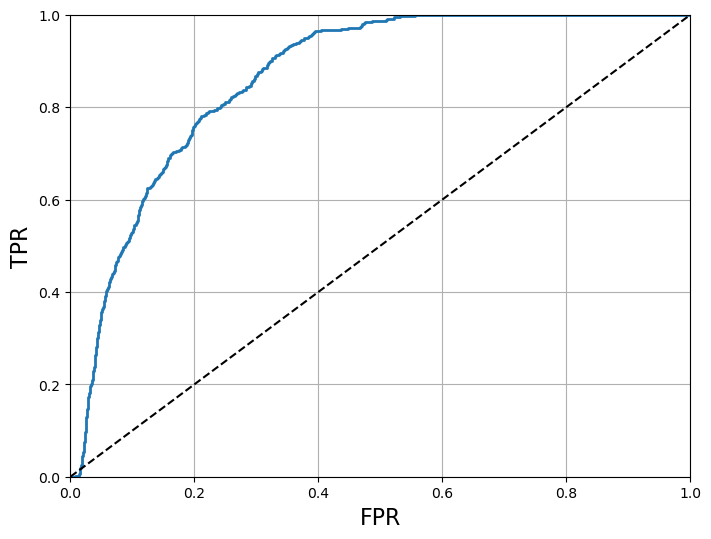

In [187]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('FPR', fontsize=16)
    plt.ylabel('TPR', fontsize=16)
    plt.grid(True)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

In [188]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test_5, y_pred2)

0.8655981801473605